In [5]:
# 现在需要改成 横坐标是PCC(3C, RNA) 纵坐标是loop distance 的散点图 然后突出显示PCC(3C, RNA)>0.5的那些点（线？框？）

In [329]:
library(ggplot2)
library(dplyr)

options(repr.plot.width=36/25.4,repr.plot.height=36/25.4,repr.plot.res=400)

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
selected_loops=read.csv(paste0(indir,'/selected_loops.csv'))

In [3]:
dim(selected_loops);head(selected_loops)

[1] 31704     8

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance,PCC_5hmCG_RNA
,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<dbl>
1,463,504,chr1,463,ENSMUSG00000002459.17,-0.20726372,41,-0.15418849
2,641,685,chr1,641,ENSMUSG00000033740.17,0.08479841,44,-0.30560963
3,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.27949825,19,-0.30778747
4,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.38296159,30,0.04769515
5,1083,1125,chr1,1083,ENSMUSG00000048960.13,0.38296159,42,0.04769515
6,1198,1166,chr1,1198,ENSMUSG00000057715.13,0.45005256,32,0.58763418


In [4]:
selected_loops$'loop_distance' = 10*selected_loops$'bin_distance'
head(selected_loops)

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance,PCC_5hmCG_RNA,loop_distance
,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<dbl>,<dbl>
1,463,504,chr1,463,ENSMUSG00000002459.17,-0.20726372,41,-0.15418849,410
2,641,685,chr1,641,ENSMUSG00000033740.17,0.08479841,44,-0.30560963,440
3,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.27949825,19,-0.30778747,190
4,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.38296159,30,0.04769515,300
5,1083,1125,chr1,1083,ENSMUSG00000048960.13,0.38296159,42,0.04769515,420
6,1198,1166,chr1,1198,ENSMUSG00000057715.13,0.45005256,32,0.58763418,320


In [264]:
library(RColorBrewer)

# 获取完整的Blues调色板（例如9个颜色）
blues_pal <- brewer.pal(9, "Blues")  # 返回颜色值从浅到深

# 截取中间到末尾的颜色（例如第4到第9个颜色）
custom_blues <- blues_pal[5:9]



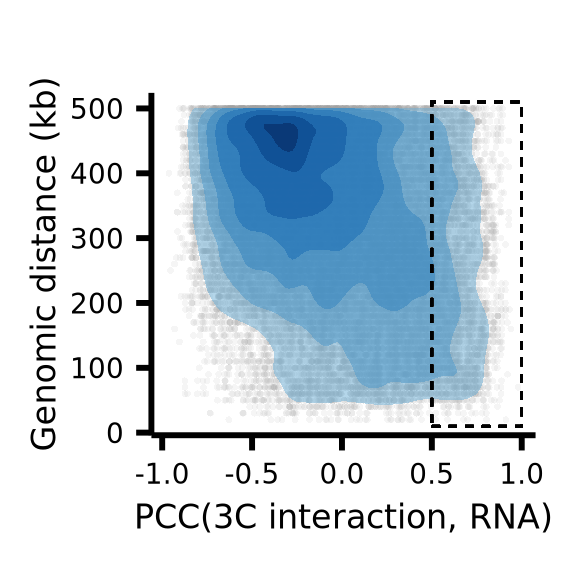

In [335]:
ggplot((selected_loops), aes(x = PCC_3C_RNA, y = loop_distance)) +
geom_point(color = "Gray 62", stroke=0, alpha=0.1, size = 0.85, shape='bullet') +
stat_density_2d(
    aes(fill = ..level.., alpha = ..level..),
    bins=8,
    geom = "polygon", 
    show.legend = FALSE
  ) +
  scale_fill_gradientn(colors = custom_blues)+
scale_alpha_continuous(range = c(0.5, 0.7)) + # Set alpha to transition from low (white) to high (blue)
geom_rect(xmin=0.5,xmax=1,ymin=10, ymax=510, fill = NA, color = "black", linetype = "22", linewidth=0.2)+
labs(title = "",
       x = "PCC(3C interaction, RNA)",
       y = "Genomic distance (kb)") +
  theme_minimal() +
  theme(
    text = element_text(size = 5),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black",family="ArialMT"),
    axis.title.x = element_text(color="black", size=6,family="ArialMT"),
    axis.title.y = element_text(color="black", size=6,family="ArialMT"),
    axis.text.x = element_text(color="black", size=5,family="ArialMT", hjust = 0.5,),
    axis.text.y = element_text(color="black", size=5,family="ArialMT"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black",family="ArialMT"),
    plot.title = element_text(hjust = 0.5, color = "black",family="ArialMT"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  ) 

In [ ]:
p <- ggplot((selected_loops), aes(x = PCC_3C_RNA, y = loop_distance)) +
geom_point(color = "Gray 62", stroke=0, alpha=0.1, size = 0.85, shape='bullet') +
stat_density_2d(
    aes(fill = ..level.., alpha = ..level..),
    bins=8,
    geom = "polygon", 
    show.legend = FALSE
  ) +
  scale_fill_gradientn(colors = custom_blues)+
scale_alpha_continuous(range = c(0.5, 0.7)) + # Set alpha to transition from low (white) to high (blue)
geom_rect(xmin=0.5,xmax=1,ymin=10, ymax=510, fill = NA, color = "black", linetype = "22", linewidth=0.2)+
labs(title = "",
       x = "PCC(3C interaction, RNA)",
       y = "Genomic distance (kb)") +
  theme_minimal() +
  theme(
    text = element_text(size = 5),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black",family="ArialMT"),
    axis.title.x = element_text(color="black", size=6,family="ArialMT"),
    axis.title.y = element_text(color="black", size=6,family="ArialMT"),
    axis.text.x = element_text(color="black", size=5,family="ArialMT", hjust = 0.5,),
    axis.text.y = element_text(color="black", size=5,family="ArialMT"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black",family="ArialMT"),
    plot.title = element_text(hjust = 0.5, color = "black",family="ArialMT"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  ) 

pdf('../../../../output/01-youth/06-m3C_supplementary_figures/04_scatterplot_PCC(3C,RNA)_distance.pdf', width=36/25.4,height=36/25.4, family="ArialMT")
print(p)
dev.off()

png 
  2

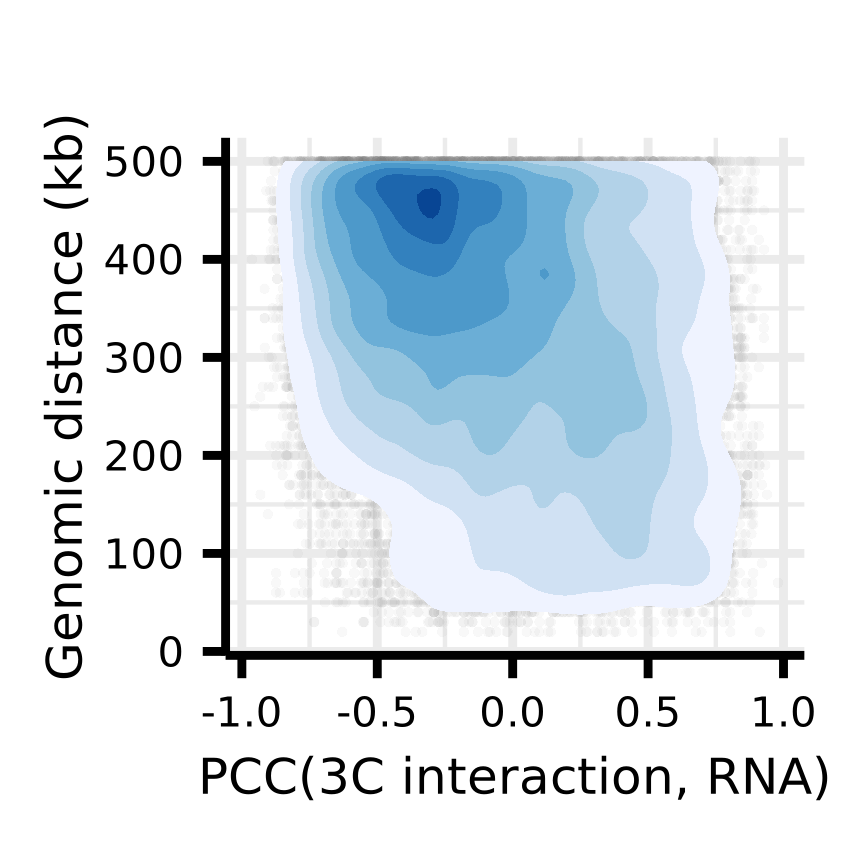

In [186]:
ggplot((selected_loops), aes(x = PCC_3C_RNA, y = loop_distance)) +
geom_point(color = "Gray 52", stroke=0, alpha=0.05, size = 0.85, shape='bullet') +
stat_density_2d(
    aes(fill = ..level.., alpha = ..level..),
    bins=10,
    geom = "polygon", 
    show.legend = FALSE
  ) +
  scale_fill_distiller(palette = "Blues", direction = 1)+
  scale_alpha_continuous(range = c(1, 1)) + # Set alpha to transition from low (white) to high (blue)
labs(title = "",
       x = "PCC(3C interaction, RNA)",
       y = "Genomic distance (kb)") +
  theme_minimal() +
  theme(
    text = element_text(size = 5),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black",family="ArialMT"),
    axis.title.x = element_text(color="black", size=6,family="ArialMT"),
    axis.title.y = element_text(color="black", size=6,family="ArialMT"),
    axis.text.x = element_text(color="black", size=5,family="ArialMT", hjust = 0.5,),
    axis.text.y = element_text(color="black", size=5,family="ArialMT"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black",family="ArialMT"),
    plot.title = element_text(hjust = 0.5, color = "black",family="ArialMT")
  ) 

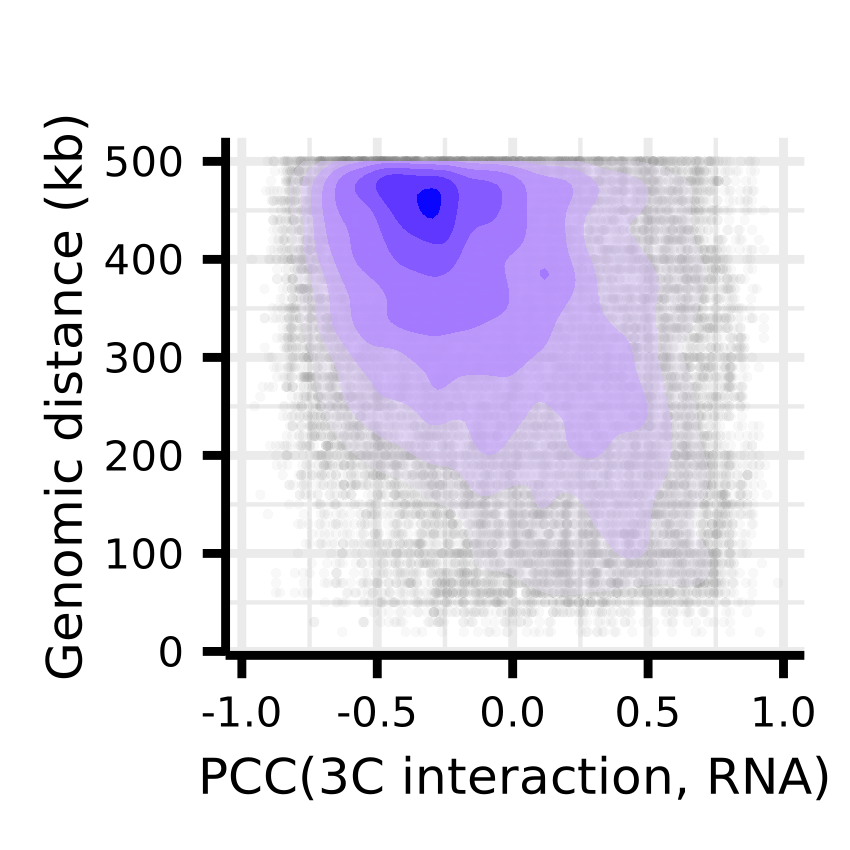

In [145]:
ggplot((selected_loops), aes(x = PCC_3C_RNA, y = loop_distance)) +
geom_point(color = "Gray 52", stroke=0, alpha=0.05, size = 0.85, shape='bullet') +
stat_density_2d(
    aes(fill = ..level.., alpha = log(..level..)),bins=10,
    geom = "polygon", 
    show.legend = FALSE
  ) +
  scale_fill_gradient(low = "white", high = "blue") + # Custom blue-to-white color gradient
  scale_alpha_continuous(range = c(0, 0.9)) + # Set alpha to transition from low (white) to high (blue)
labs(title = "",
       x = "PCC(3C interaction, RNA)",
       y = "Genomic distance (kb)") +
  theme_minimal() +
  theme(
    text = element_text(size = 5),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black",family="ArialMT"),
    axis.title.x = element_text(color="black", size=6,family="ArialMT"),
    axis.title.y = element_text(color="black", size=6,family="ArialMT"),
    axis.text.x = element_text(color="black", size=5,family="ArialMT", hjust = 0.5,),
    axis.text.y = element_text(color="black", size=5,family="ArialMT"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black",family="ArialMT"),
    plot.title = element_text(hjust = 0.5, color = "black",family="ArialMT")
  ) 

In [79]:
sum(selected_loops$'PCC_3C_RNA'>0.5)

[1] 3747